In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [15]:
df = pd.read_csv('/Users/ephraim/Downloads/athlete_simulation_data.csv')

In [16]:
def calculate_resting_days(group):
    resting_days = []
    current_resting = 0
    for workload in group['game_workload']:
        if workload == 0:
            current_resting += 1
        else:
            current_resting = 0
        resting_days.append(current_resting)
    return pd.Series(resting_days, index=group.index)

df["injuries_status"] = df["injuries_status"].map({"Yes": 1, "No": 0, "injured": 1, "non_injured": 0}).fillna(0)
df['resting'] = df.groupby('athlete_id', group_keys=False).apply(calculate_resting_days).astype(int)

##Acute load and ACWR
def create_injury_risk_features(df):
    df = df.sort_values(by=['athlete_id', 'date']).copy()
    
    df['acute_load'] = df.groupby('athlete_id')['game_workload'].rolling(7, min_periods=1).mean().values
    
    chronic_load = df.groupby('athlete_id')['game_workload'].rolling(28, min_periods=1).mean().values
    df['acwr'] = df['acute_load'] / np.where(chronic_load == 0, 0.001, chronic_load)
    
    df['workload_change'] = df.groupby('athlete_id')['game_workload'].pct_change()
    df['rest_days_7d'] = df.groupby('athlete_id')['resting'].rolling(7, min_periods=1).sum().values

    ##Injury History
    df['injuries_30d'] = df.groupby('athlete_id')['injuries_status'].rolling(30, min_periods=1).sum().values
    df['days_since_injury'] = df.groupby('athlete_id')['injuries_status'].apply(
        lambda x: x.groupby((x != 0).cumsum()).cumcount()
    ).values

    ##HRV
    df['hrv_7d_avg'] = df.groupby('athlete_id')['hrv'].rolling(7, min_periods=1).mean().values

    ##Sleep
    df['sleep_quality_7d_avg'] = df.groupby('athlete_id')['sleep_quality_score'].rolling(7, min_periods=1).mean().values
    df['sleep_hours_7d_avg'] = df.groupby('athlete_id')['sleep_hours'].rolling(7, min_periods=1).mean().values

    ##Fatigue
    df['fatigue_trend'] = df.groupby('athlete_id')['fatigue_score'].rolling(7, min_periods=1).mean().values

    ##Environment
    if 'environment' in df.columns:
        df['env_risk_score'] = df['environment'].map({0: 0.0, 1: 0.5, 2: 1.0}).fillna(0.0)
    else:
        df['env_risk_score'] = 0.0

   ##Asymmetry
    if 'stronger_limb_score' in df.columns and 'weaker_limb_score' in df.columns:
        denom = np.where(df['stronger_limb_score'] == 0, 1.0, df['stronger_limb_score'])
        df['limb_asymmetry'] = ((df['stronger_limb_score'] - df['weaker_limb_score']) / denom) * 100
    else:
        df['limb_asymmetry'] = 0.0

    # AGE & BIO-SEX ---
    df['age_factor'] = (df['age'] - df['age'].mean()) / df['age'].std()
    df['is_female'] = df['bio_sex'].map({'female': 1, 'Female': 1, 'male': 0, 'Male': 0}).fillna(0)

    # FINAL RISK CALCULATION MATRIX ---
    mean_workload = df['acute_load'].mean()
    std_workload = df['acute_load'].std() if df['acute_load'].std() != 0 else 1.0
    df['workload_risk'] = 1 / (1 + np.exp(-((df['acute_load'] - mean_workload) / std_workload)))

  
    df['overall_risk'] = (
        ((df['acwr'] > 1.5).astype(float) * 0.35) +
        ((df['injuries_30d'] > 0).astype(float) * 0.20) +
        ((df['limb_asymmetry'] / 100.0) * 0.15) +
        ((1 - (df['hrv_7d_avg'] / df['hrv_7d_avg'].max()).fillna(0)) * 0.10) +
        ((1 - (df['sleep_quality_7d_avg'] / 4.0)) * 0.05) +
        ((df['fatigue_trend'] / 10.0).clip(0, 1) * 0.05) +
        (((df['age'] - df['age'].min()) / (df['age'].max() - df['age'].min() + 0.001)) * 0.04) +
        (df['env_risk_score'] * 0.03) +
        (df['workload_risk'] * 0.02) +
        (df['is_female'] * 0.01)
    )

    return df

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = create_injury_risk_features(df)
df = df.bfill().ffill()


/var/folders/wf/dcvnwgns65vg06nypd8d0fl40000gn/T/ipykernel_6704/930650939.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['resting'] = df.groupby('athlete_id', group_keys=False).apply(calculate_resting_days).astype(int)


In [17]:
df = df.sort_values(['athlete_id', 'date'])
df['injury_next_7d'] = df.groupby('athlete_id')['injuries_status'].transform(
    lambda x: x.rolling(window=7, min_periods=1).max().shift(-6)
).fillna(0).astype(int)

In [18]:
from sklearn.ensemble import RandomForestClassifier

feature_cols = [
    'acwr', 'injuries_30d', 'days_since_injury', 'limb_asymmetry',
    'hrv_7d_avg', 'sleep_quality_7d_avg', 'sleep_hours_7d_avg',
    'fatigue_trend', 'env_risk_score', 'workload_risk',
    'age_factor', 'is_female', 'workload_change', 'rest_days_7d'
]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['injury_next_7d']

df['date'] = pd.to_datetime(df['date'])
split_date = pd.to_datetime(df['date'].view('int64').quantile(0.8))

X_train = X[df['date'] <= split_date]
X_test  = X[df['date'] >  split_date]
y_train = y[df['date'] <= split_date]
y_test  = y[df['date'] >  split_date]

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
print(f"Data split successfully at: {split_date.strftime('%Y-%m-%d')}")
print(f"Training rows: {X_train.shape[0]} | Testing rows: {X_test.shape[0]}")
print("Model trained successfully!")

/var/folders/wf/dcvnwgns65vg06nypd8d0fl40000gn/T/ipykernel_6704/3985737848.py:14: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  split_date = pd.to_datetime(df['date'].view('int64').quantile(0.8))


Data split successfully at: 2024-05-23
Training rows: 7200 | Testing rows: 1800
Model trained successfully!


In [20]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      1674
           1       0.12      0.20      0.15       126

    accuracy                           0.84      1800
   macro avg       0.53      0.54      0.53      1800
weighted avg       0.88      0.84      0.86      1800

AUC-ROC Score: 0.6121541408279758


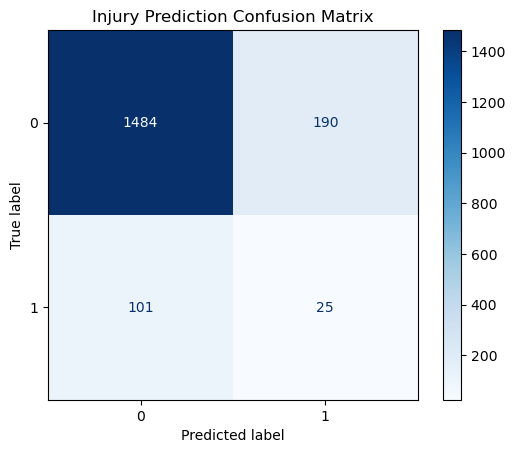

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
plt.title("Injury Prediction Confusion Matrix")
plt.show()

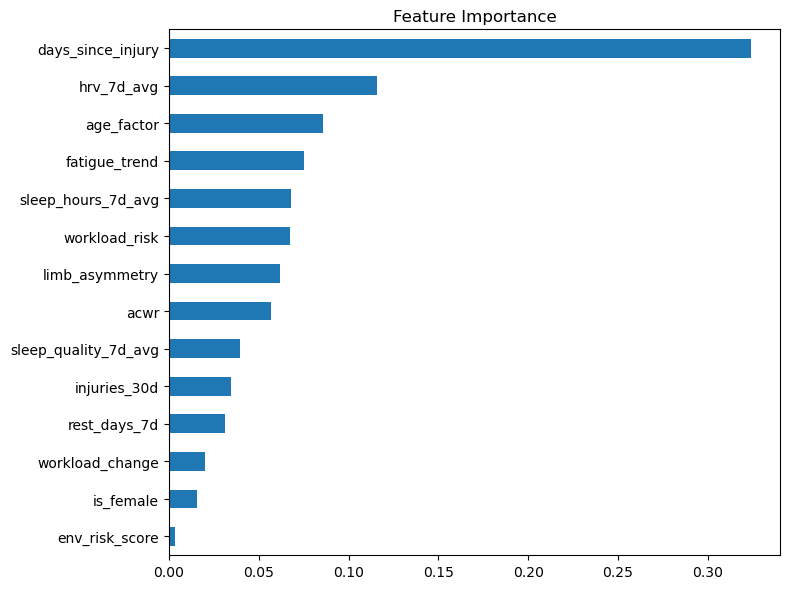

In [22]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

In [23]:
injury_risk_percentage = model.predict_proba(X_test)[:, 1] * 100

risk_profile = pd.DataFrame(index=X_test.index)

risk_profile['Athlete_ID'] = df.loc[X_test.index, 'athlete_id']
risk_profile['Date'] = df.loc[X_test.index, 'date']

risk_profile['Injury_Risk_%'] = np.round(injury_risk_percentage, 2)
risk_profile['Actual_Injury_Happened'] = y_test

risk_profile = risk_profile.sort_values(by='Injury_Risk_%', ascending=False)

print("--- TOP 10 ATHLETES AT RISK OF INJURY ---")
print(risk_profile.head(10).to_string(index=False))

--- TOP 10 ATHLETES AT RISK OF INJURY ---
Athlete_ID       Date  Injury_Risk_%  Actual_Injury_Happened
   ATH_038 2024-06-21          85.80                       1
   ATH_032 2024-06-08          85.04                       1
   ATH_048 2024-06-16          84.96                       1
   ATH_039 2024-06-08          84.32                       1
   ATH_040 2024-05-27          84.28                       1
   ATH_030 2024-06-02          84.10                       1
   ATH_017 2024-06-27          83.69                       0
   ATH_036 2024-06-23          83.09                       0
   ATH_012 2024-05-29          82.09                       1
   ATH_023 2024-06-16          81.63                       1


In [24]:
def predict_individual_injury_risk(athlete_features_df, trained_model):
    """
    Takes a dataframe containing a single row (or multiple rows) of an athlete's 
    current daily features and returns their percentage risk of injury.
    """
    cleaned_features = athlete_features_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    risk_prob = trained_model.predict_proba(cleaned_features)[0, 1]
    risk_percentage = risk_prob * 100
    return f"Athlete Injury Risk for the next 7 days: {risk_percentage:.1f}%"


sample_athlete_data = X_test.iloc[[0]] 

risk_result = predict_individual_injury_risk(sample_athlete_data, model)
print(risk_result)

Athlete Injury Risk for the next 7 days: 30.3%


In [25]:
def predict_individual_injury_risk(athlete_features_df, trained_model):
    """
    Takes a dataframe containing a single row (or multiple rows) of an athlete's 
    current daily features and returns their percentage risk of injury.
    """
    cleaned_features = athlete_features_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    risk_prob = trained_model.predict_proba(cleaned_features)[0, 1]
    risk_percentage = risk_prob * 100
    return f"Athlete Injury Risk for the next 7 days: {risk_percentage:.1f}%"


sample_athlete_data = X_test.iloc[[11]] 

risk_result = predict_individual_injury_risk(sample_athlete_data, model)
print(risk_result)

Athlete Injury Risk for the next 7 days: 32.1%
